# Manual Pipeline: RA Cohort from MIMIC-IV via MAP

End-to-end phenotyping pipeline for the agent task:
> *"Build a cohort of rheumatoid arthritis patients from MIMIC-IV."*

This notebook implements the **MAP (Multimodal Automated Phenotyping)** algorithm, which combines codified EHR features (ICD/PheCode counts) with NLP features (CUI mentions in clinical notes) to produce a per-patient phenotype probability score. Patients above the MAP decision boundary are labeled as cases.

**Pipeline stages:**
1. **Load MIMIC-IV EHR data** — diagnosis codes (`diagnoses_icd`) and admissions (`admissions`)
2. **ONCE feature discovery** — reads pre-computed ONCE output files to get the ranked PheCode and CUI feature sets for RA
3. **ICD → PheCode rollup** — maps raw ICD-9/ICD-10 codes to PheCodes using the standard v1.2 crosswalk
4. **Build MAP feature matrix** — pivots PheCodes into a wide patient × feature count matrix; filters to patients with any ONCE-identified feature
5. **NLP feature extraction** (`note_ner`) — extracts CUI mentions from discharge notes using MedSpaCy, filtered by the ONCE narrative vocabulary; merged into the feature matrix
6. **Run MAP** — calls the MAP R script via subprocess; fits a per-feature Poisson mixture model and returns per-patient scores and binary phenotype labels
7. **Inspect and validate** — score distribution, case/control counts, and a sanity check comparing RA ICD code burden between MAP cases and controls

**Data availability:**
- MIMIC-IV-Note (`mimiciv/note/discharge.csv.gz`) is required for Step 5. Set `NOTES_AVAILABLE = True` in the setup cell to enable the NLP step.
- If notes are unavailable, admission count is used as a proxy for note count (1 admission ≈ 1 discharge note), and MAP runs on PheCode features only.

In [17]:
import os
import sys
import pandas as pd
from matplotlib import pyplot as plt
import warnings

warnings.filterwarnings("ignore")

# Paths
NOTEBOOK_DIR = os.path.abspath(".")
PROJECT_DIR = os.path.abspath("..")
MIMIC_DIR = os.path.join(PROJECT_DIR, "mimiciv", "hosp")

# Add m4-pheno to sys.path so local modules import without install
if NOTEBOOK_DIR not in sys.path:
    sys.path.insert(0, NOTEBOOK_DIR)

PHECODE_MAP = os.path.join(NOTEBOOK_DIR, "Phecode_map_v1_2_icd9_icd10cm.csv")
ONCE_CODIFIED = os.path.join(
    NOTEBOOK_DIR, "ONCE_Rheumatoid Arthritis_PheCode714.1_cos0.165.csv"
)
ONCE_NARRATIVE = os.path.join(
    NOTEBOOK_DIR,
    "ONCE_Rheumatoid Arthritis_C0003873_titlecos0.5_titlecut0.3_exactFALSE.csv",
)

# Toggle: set True if MIMIC-IV-Note is available under mimiciv/note/
NOTES_AVAILABLE = False
NOTES_FILE = os.path.join(PROJECT_DIR, "mimiciv", "note", "discharge.csv.gz")

print("MIMIC_DIR  :", MIMIC_DIR, "-> exists:", os.path.isdir(MIMIC_DIR))
print(
    "PHECODE_MAP:",
    os.path.basename(PHECODE_MAP),
    "-> exists:",
    os.path.isfile(PHECODE_MAP),
)
print(
    "ONCE_COD   :",
    os.path.basename(ONCE_CODIFIED),
    "-> exists:",
    os.path.isfile(ONCE_CODIFIED),
)
print(
    "ONCE_NAR   :",
    os.path.basename(ONCE_NARRATIVE),
    "-> exists:",
    os.path.isfile(ONCE_NARRATIVE),
)
print(
    "NOTES_FILE :",
    os.path.basename(NOTES_FILE),
    "-> exists:",
    os.path.isfile(NOTES_FILE),
)

MIMIC_DIR  : /Users/irithkatiyar/Desktop/bmi702/bmi702-project/mimiciv/hosp -> exists: True
PHECODE_MAP: Phecode_map_v1_2_icd9_icd10cm.csv -> exists: True
ONCE_COD   : ONCE_Rheumatoid Arthritis_PheCode714.1_cos0.165.csv -> exists: True
ONCE_NAR   : ONCE_Rheumatoid Arthritis_C0003873_titlecos0.5_titlecut0.3_exactFALSE.csv -> exists: True
NOTES_FILE : discharge.csv.gz -> exists: True


## Step 1 — Load MIMIC-IV EHR Data

Two tables are loaded from the MIMIC-IV `hosp` module:

- **`diagnoses_icd`** — one row per diagnosis per hospital admission, with raw ICD-9 or ICD-10 codes. This is the primary input to the PheCode rollup in Step 3.
- **`admissions`** — one row per hospital admission. Used here only to count admissions per patient as a proxy for the number of discharge notes (needed by MAP as the "note count" denominator). When `NOTES_AVAILABLE = True`, this proxy is replaced by actual note counts from MIMIC-IV-Note.

In [18]:
# ICD diagnosis codes
diagnoses_df = pd.read_csv(
    os.path.join(MIMIC_DIR, "diagnoses_icd.csv.gz"),
    dtype={"icd_code": str, "icd_version": int},
)
print(
    f"diagnoses_icd : {len(diagnoses_df):>10,} rows  |  "
    f"{diagnoses_df['subject_id'].nunique():,} unique patients"
)
diagnoses_df.head(100)

diagnoses_icd :  6,364,488 rows  |  223,291 unique patients


,subject_id,hadm_id,seq_num,icd_code,icd_version
0,10000032,22595853,1,5723,9
1,10000032,22595853,2,78959,9
2,10000032,22595853,3,5715,9
3,10000032,22595853,4,07070,9
4,10000032,22595853,5,496,9
...,...,...,...,...,...
95,10000635,20642640,8,I471,10
96,10000635,20642640,9,Z20822,10
97,10000635,26134563,1,42789,9
98,10000635,26134563,2,25000,9


In [19]:
# Admissions: used as a proxy for note count (1 admission ~ 1 discharge note)
# MAP needs a note count per patient; without MIMIC-IV-Note, admission count
# is the closest available signal from standard MIMIC-IV
admissions_df = pd.read_csv(
    os.path.join(MIMIC_DIR, "admissions.csv.gz"),
    usecols=["subject_id", "hadm_id"],
)
print(
    f"admissions : {len(admissions_df):>10,} rows  |  "
    f"{admissions_df['subject_id'].nunique():,} unique patients"
)
admissions_df.head()

admissions :    546,028 rows  |  223,452 unique patients


,subject_id,hadm_id
0,10000032,22595853
1,10000032,22841357
2,10000032,25742920
3,10000032,29079034
4,10000068,25022803


## Step 2 — ONCE: Automated Feature Discovery for RA

**ONCE (Online NLP-assisted Clinical Embedding)** is a tool that, given a phenotype concept, returns a ranked list of EHR features most associated with that concept. It produces two output files used here:

- **Codified file** (`ONCE_..._PheCode714.1_cos0.165.csv`) — ranked PheCode and RxNorm features with cosine similarity and importance scores. Features with `phenotyping_features = True` are the high-confidence set used to build the MAP feature matrix.
- **Narrative file** (`ONCE_..._C0003873_....csv`) — ranked CUI + term pairs derived from clinical note embeddings. These define the NLP vocabulary: for each term, MedSpaCy searches discharge notes and flags mentions of that CUI.

`get_once_features()` reads both files and returns structured lists for downstream use. **Known issue:** `once.py` reads the narrative file with `sep='|'` but the local CSV is comma-separated, so `nlp_target_cuis` comes back empty from that call. The cell below re-reads the narrative file with the correct separator to recover the 442 CUI terms.

In [20]:
from once import get_once_features

once_features = get_once_features(ONCE_CODIFIED, ONCE_NARRATIVE)

print("=== Codified features ===")
print(f"  Total rows           : {len(once_features['codified'])}")
print(f"  phenotyping_features : {len(once_features['codified_list'])}")
print(f"  Sample               : {once_features['codified_list'][:5]}")

print("=== Narrative features ===")
print(
    f"  nlp_target_cuis from once.py : {len(once_features['nlp_target_cuis'])} "
    "(expected 0 -- sep='|' mismatch)"
)

narrative_df = pd.read_csv(ONCE_NARRATIVE)
# once.py expects columns 'CUI' / 'Term'; actual columns are lowercase
narrative_df.columns = [c.upper() for c in narrative_df.columns]
nlp_target_cuis = [
    {"term": row["TERM"], "cui": row["CUI"]}
    for _, row in narrative_df[["TERM", "CUI"]].dropna().iterrows()
]
print(f"  nlp_target_cuis after manual load : {len(nlp_target_cuis)}")
print(f"  Sample : {nlp_target_cuis[:3]}")

print("=== Full ONCE codified table ===")
once_features["codified"]

=== Codified features ===
  Total rows           : 278
  phenotyping_features : 41
  Sample               : ['PheCode:714.1', 'PheCode:714.2', 'PheCode:716.1', 'PheCode:041.21', 'RXNORM:614391']
=== Narrative features ===
  nlp_target_cuis from once.py : 0 (expected 0 -- sep='|' mismatch)
  nlp_target_cuis after manual load : 442
  Sample : [{'term': 'Rheumatoid Arthritis', 'cui': 'C0003873'}, {'term': 'Rheumatoid Nodule', 'cui': 'C0035450'}, {'term': 'Seropositive rheumatoid arthritis', 'cui': 'C0409651'}]
=== Full ONCE codified table ===


,Variable,Description,target_similarity,importance_score,phenotyping_features,expanded_features
0,PheCode:714.1,rheumatoid arthritis,1.000,0.631,True,True
1,PheCode:714.2,juvenile rheumatoid arthritis,0.533,0.429,True,True
2,PheCode:716.1,unspecified polyarthropathy or polyarthritis,0.502,0.399,True,True
3,PheCode:041.21,rheumatic fever / chorea,0.424,0.393,True,True
4,RXNORM:614391,abatacept,0.469,0.392,True,True
...,...,...,...,...,...,...
273,RXNORM:6038,isoniazid,0.173,0.067,False,False
274,RXNORM:709271,certolizumab,0.257,NaN,False,False
275,ShortName:Mono - Fra,mono - fra,0.194,NaN,False,False
276,ShortName:MCV,mcv,0.193,NaN,False,False


In [21]:
# Extract PheCode features (strip 'PheCode:' prefix to match pivot column names after rollup)
once_phecodes_raw = [
    v for v in once_features["codified_list"] if v.startswith("PheCode:")
]
once_phecodes = [v.replace("PheCode:", "") for v in once_phecodes_raw]

print(f"ONCE PheCode features : {len(once_phecodes)}")
print(once_phecodes)

MAIN_ICD_COL = "714.1"  # primary RA MAP anchor
assert MAIN_ICD_COL in once_phecodes, "Main anchor must be in ONCE codified list"

ONCE PheCode features : 28
['714.1', '714.2', '716.1', '041.21', '714', '716.8', '696.42', '740.12', '740.2', '709.2', '715.2', '711.2', '274.2', '717', '709.7', '727.2', '710.2', '446.9', '739', '274.11', '716.9', '446.6', '741.5', '741.6', '711.1', '729.1', '696.4', '726.3']


## Step 3 — ICD → PheCode Rollup

Raw MIMIC-IV diagnosis codes are stored without decimal points (e.g., `71410` instead of `714.10`). `rollup_icd_to_phecode()` normalizes these by inserting a `.` at position 3 for codes longer than 3 characters, then performs a left-join against the **PheCode Map v1.2** crosswalk (`Phecode_map_v1_2_icd9_icd10cm.csv`), which covers both ICD-9-CM and ICD-10-CM.

The result adds two columns to the diagnosis table:
- **`Phecode`** — the mapped PheCode string (e.g., `"714.1"`)
- **`PhecodeString`** — human-readable label (e.g., `"rheumatoid arthritis"`)

Rows where no PheCode match exists (~7.8% of codes) retain `NaN` and are excluded from the pivot in Step 4.

In [22]:
from rollup import rollup_icd_to_phecode

phecode_df = rollup_icd_to_phecode(
    diagnoses_df,
    icd_column="icd_code",
    mapping_file=PHECODE_MAP,
)

n_mapped = phecode_df["Phecode"].notna().sum()
n_unmapped = phecode_df["Phecode"].isna().sum()
print(f"Total rows          : {len(phecode_df):,}")
print(f"Mapped to PheCode   : {n_mapped:,}  ({100 * n_mapped / len(phecode_df):.1f}%)")
print(f"Unmapped (no entry) : {n_unmapped:,}")

ra_raw = phecode_df[phecode_df["Phecode"] == MAIN_ICD_COL]
print(f"Patients with PheCode {MAIN_ICD_COL} (RA): {ra_raw['subject_id'].nunique():,}")

phecode_df[["subject_id", "icd_code", "icd_version", "Phecode", "PhecodeString"]].head(
    10
)

Total rows          : 6,443,112
Mapped to PheCode   : 5,943,457  (92.2%)
Unmapped (no entry) : 499,655
Patients with PheCode 714.1 (RA): 3,477


,subject_id,icd_code,icd_version,Phecode,PhecodeString
0,10000032,572.3,9,571.81,Portal hypertension
1,10000032,789.59,9,572,Ascites (non malignant)
2,10000032,571.5,9,571.51,Cirrhosis of liver without mention of alcohol
3,10000032,070.70,9,070.3,Viral hepatitis C
4,10000032,496,9,496,Chronic airway obstruction
5,10000032,296.80,9,296.1,Bipolar
6,10000032,309.81,9,300.9,Posttraumatic stress disorder
7,10000032,V15.82,9,318,Tobacco use disorder
8,10000032,070.71,9,070.3,Viral hepatitis C
9,10000032,789.59,9,572,Ascites (non malignant)


## Step 4 — Build MAP Feature Matrix

The MAP algorithm requires two inputs:

1. **`mat_df`** — a wide patient × feature count matrix. Each row is a patient (`subject_id`), each column is an ONCE-identified PheCode, and each value is the number of times that PheCode appeared across all that patient's admissions. Only the 28 PheCodes flagged as `phenotyping_features = True` by ONCE are included as columns. Patients with zero counts across all ONCE features are dropped — this scopes the study population to individuals with at least some RA-related signal (~12,476 patients out of 222,960).

2. **`note_df`** — a per-patient note count used by MAP as the exposure denominator in the Poisson model (i.e., "how many notes does this patient have?"). Without MIMIC-IV-Note, admission count is used as the best available proxy.

A pre-MAP filter drops features with fewer than 20 non-zero patients — MAP's `flexmix` EM fitting requires enough non-zero observations to form two components per feature. The anchor feature (`714.1`) is always kept regardless of sparsity.

In [23]:
# Full PheCode pivot (all patients x all PheCodes)
mapped = phecode_df.dropna(subset=["Phecode"])
all_phecode_wide = mapped.pivot_table(
    index="subject_id",
    columns="Phecode",
    aggfunc="size",
    fill_value=0,
)
print(
    f"Full pivot : {all_phecode_wide.shape[0]:,} patients x {all_phecode_wide.shape[1]:,} PheCodes"
)

# Restrict columns to ONCE-identified PheCodes present in the data
available_once_cols = [c for c in once_phecodes if c in all_phecode_wide.columns]
missing_once_cols = [c for c in once_phecodes if c not in all_phecode_wide.columns]
print(f"ONCE PheCodes available : {len(available_once_cols)} / {len(once_phecodes)}")
if missing_once_cols:
    print(f"Not in MIMIC-IV data    : {missing_once_cols}")

# Main anchor always first column
feature_cols = [MAIN_ICD_COL] + [c for c in available_once_cols if c != MAIN_ICD_COL]
mat_full = all_phecode_wide[feature_cols]

# Keep patients with at least one ONCE-feature occurrence
mat_df = mat_full[mat_full.sum(axis=1) > 0].copy()
print(f"Study population : {mat_df.shape[0]:,} patients x {mat_df.shape[1]} features")
print(f"  With >= 1 RA PheCode ({MAIN_ICD_COL}) : {(mat_df[MAIN_ICD_COL] > 0).sum():,}")
mat_df.head()

Full pivot : 222,960 patients x 1,785 PheCodes
ONCE PheCodes available : 27 / 28
Not in MIMIC-IV data    : ['696.4']
Study population : 12,476 patients x 27 features
  With >= 1 RA PheCode (714.1) : 3,477


Phecode,714.1,714.2,716.1,041.21,714,716.8,696.42,740.12,740.2,709.2,...,446.9,739,274.11,716.9,446.6,741.5,741.6,711.1,729.1,726.3
subject_id,,,,,,,,,,,,,,,,,,,,,
10002013,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
10002428,0,0,0,0,0,0,0,0,0,7,...,0,0,0,0,0,0,0,0,0,0
10002443,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
10002769,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
10002976,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [24]:
# note_df: admissions per patient as proxy for discharge note count
note_df = admissions_df.groupby("subject_id").size().to_frame("note_count")
# Align to study population; patients absent from admissions get count of 1
note_df = note_df.reindex(mat_df.index).fillna(1).astype(int)

print(f"note_df : {len(note_df):,} patients")
print(note_df.describe().T)

note_df : 12,476 patients
              count      mean       std  min  25%  50%  75%    max
note_count  12476.0  4.767714  6.697918  1.0  1.0  3.0  5.0  103.0


## Step 5 — NLP Feature Extraction via `note_ner`

This step extracts **CUI (Concept Unique Identifier) mentions** from MIMIC-IV discharge notes using **MedSpaCy**, a clinical NLP library built on spaCy. The target vocabulary comes from the ONCE narrative output: 442 `(term, CUI)` pairs associated with RA.

For each note, `extract_cui_features()`:
1. Runs the MedSpaCy pipeline (sentence detection → target matching → negation/context detection)
2. Identifies spans matching any ONCE-provided term literal
3. **Filters out** negated mentions (e.g., *"no rheumatoid arthritis"*), uncertain mentions, and family history mentions — keeping only positive, asserted findings
4. Returns a long-format DataFrame of `(subject_id, cui, count=1)` rows

`aggregate_features()` then pivots this into a wide binary matrix (patient × CUI) which is joined onto `mat_df`, giving MAP both codified and NLP signals.

**Note on performance:** MedSpaCy uses rule-based token matching (not a transformer), so GPU does not help. For the full MIMIC-IV-Note discharge corpus (~330k notes), use `nlp.pipe(batch_size=256, n_process=4)` and save the output to parquet — this is a one-time preprocessing step. See the commented cell below for the optimized version.

**Toggle:** Set `NOTES_AVAILABLE = True` in the setup cell and ensure `NOTES_FILE` points to `mimiciv/note/discharge.csv.gz`.

In [25]:
# if NOTES_AVAILABLE:
#     from note_ner import extract_cui_features, aggregate_features

#     notes_df = pd.read_csv(NOTES_FILE, usecols=["subject_id", "text"])
#     notes_df = notes_df[notes_df["subject_id"].isin(mat_df.index)]

#     # Override note_df with real note counts
#     note_df = (
#         notes_df.groupby("subject_id")
#         .size()
#         .to_frame("note_count")
#         .reindex(mat_df.index)
#         .fillna(0)
#         .astype(int)
#     )

#     cui_long = extract_cui_features(
#         notes_df,
#         text_column="text",
#         id_column="subject_id",
#         target_cuis=nlp_target_cuis,  # built from ONCE narrative above
#     )
#     print(
#         f"CUI mentions : {len(cui_long):,} rows  across  {cui_long['subject_id'].nunique():,} patients"
#     )

#     cui_wide = aggregate_features(
#         cui_long, id_column="subject_id", feature_column="cui"
#     )
#     mat_df = mat_df.join(cui_wide, how="left").fillna(0)
#     print(f"mat_df with NLP : {mat_df.shape}")
# else:
#     print("NOTES_AVAILABLE=False -- NLP step skipped.")
#     print(f"mat_df uses PheCode features only: {mat_df.shape}")

In [26]:
# ── Optimized one-time NLP preprocessing with ONCE CUIs ──────────────────────
#
# Run this cell ONCE on the full MIMIC-IV-Note discharge corpus and save the
# output to parquet. Subsequent runs load the parquet instead of re-processing.
#
# MedSpaCy uses rule-based token matching (not a transformer), so GPU does NOT
# help. Parallelism via n_process is the primary speedup lever.
#
# Requirements:
#   - MIMIC-IV-Note discharge notes at NOTES_FILE (discharge.csv.gz)
#   - nlp_target_cuis built in Step 2 (442 ONCE narrative CUI terms for RA)
#   - pip install medspacy

# import medspacy
# import os
# from note_ner import aggregate_features
#
# CUI_PARQUET = os.path.join(NOTEBOOK_DIR, "cui_features_ra.parquet")
#
# if os.path.exists(CUI_PARQUET):
#     # Fast path: load pre-computed CUI features
#     cui_long = pd.read_parquet(CUI_PARQUET)
#     print(f"Loaded cached CUI features: {cui_long.shape}")
#
# else:
#     # Slow path: run NLP extraction on all discharge notes
#     # Filter notes to the study population first to reduce volume
#     notes_df = pd.read_csv(NOTES_FILE, usecols=["subject_id", "text"])
#     notes_df = notes_df[notes_df["subject_id"].isin(mat_df.index)].reset_index(drop=True)
#     print(f"Notes for study population: {len(notes_df):,} rows, {notes_df['subject_id'].nunique():,} patients")
#
#     # Build MedSpaCy pipeline with only the components needed
#     # Disabling the parser and tagger avoids unnecessary computation
#     nlp = medspacy.load(enable=["sentencizer", "medspacy_target_matcher", "medspacy_context"])
#
#     # Add ONCE narrative terms as target rules (one rule per CUI term)
#     from medspacy.target_matcher import TargetRule
#     rules = [TargetRule(literal=item["term"], category=item["cui"]) for item in nlp_target_cuis]
#     nlp.get_pipe("medspacy_target_matcher").add(rules)
#
#     # Process notes in parallel batches
#     # n_process=-1 uses all available CPU cores; batch_size=256 is a good default
#     extracted = []
#     for doc, subject_id in zip(
#         nlp.pipe(notes_df["text"], batch_size=256, n_process=4),
#         notes_df["subject_id"],
#     ):
#         for ent in doc.ents:
#             if not ent._.is_negated and not ent._.is_family:
#                 extracted.append({"subject_id": subject_id, "cui": ent.label_, "count": 1})
#
#     cui_long = pd.DataFrame(extracted)
#     print(f"CUI mentions: {len(cui_long):,} rows across {cui_long['subject_id'].nunique():,} patients")
#
#     # Save to parquet so this step only runs once
#     cui_long.to_parquet(CUI_PARQUET, index=False)
#     print(f"Saved to {CUI_PARQUET}")
#
# # Aggregate to wide binary matrix (patient x CUI) and join onto feature matrix
# cui_wide = aggregate_features(cui_long, id_column="subject_id", feature_column="cui")
# mat_df = mat_df.join(cui_wide, how="left").fillna(0)
#
# # Replace proxy note counts with real discharge note counts
# note_df = (
#     notes_df.groupby("subject_id")
#     .size()
#     .to_frame("note_count")
#     .reindex(mat_df.index)
#     .fillna(0)
#     .clip(lower=1)
#     .astype(int)
# )
# print(f"mat_df with NLP features: {mat_df.shape}")
# print(f"note_df: {note_df.shape}  (real discharge note counts)")

## Step 6 — Run MAP

**MAP (Multimodal Automated Phenotyping)** fits a two-component Poisson mixture model independently for each feature. For each ONCE-identified PheCode (and CUI if NLP features are included), MAP estimates:
- A "case" component (patients who truly have RA — higher expected code count)
- A "control" component (patients without RA — lower/zero expected count)

The posterior probability of belonging to the case component is aggregated across all features into a single per-patient **MAP score** (0–1). Patients with score above a data-driven threshold are labeled `phenotype = 1` (RA case).

MAP is invoked via `run_map()`, which:
1. Writes `mat_df` and `note_df` to temporary CSV files
2. Calls `map_runner.R` via `Rscript` (uses the `PheCAP`/`MAP` R package)
3. Reads back the results CSV as a DataFrame with columns `['patient_id', 'score', 'phenotype']`

**Requirements for MAP to fit correctly:**
- `mat_df` index must be named `subject_id`
- `note_df` must have a `note_count` column with the same index
- `main_icd_col` must exactly match a column name in `mat_df` — this is the anchor feature (PheCode `714.1` for RA)
- Each feature must have ≥ 20 non-zero patients (enforced by the pre-MAP filter above); otherwise `flexmix` cannot form two components and returns `NA` log-likelihood

In [ ]:
# ── Pre-MAP validation & feature filter ────────────────────────────────────
# MAP fits a *per-feature* univariate Poisson mixture and excludes zero-count
# patients for each fit.  If a feature has only 1–9 non-zero patients, flexmix
# cannot form 2 components → "Log-likelihood: NA" on iteration 1.
# Fix: drop features with fewer than MIN_NONZERO non-zero patients (keep anchor).

MIN_NONZERO = 20  # Minimum non-zero patient count per feature
# Heuristic threshold; features present in <20 patients are too sparse to be
# informative; tunable parameter.

nonzero_counts = (mat_df > 0).sum().sort_values()
sparse_cols = nonzero_counts[
    (nonzero_counts < MIN_NONZERO) & (nonzero_counts.index != MAIN_ICD_COL)
].index.tolist()

if sparse_cols:
    print(
        f"Dropping {len(sparse_cols)} sparse features (< {MIN_NONZERO} non-zero patients):"
    )
    for c in sparse_cols:
        print(f"  {c:12s}  non-zero patients = {int(nonzero_counts[c])}")
    mat_df = mat_df.drop(columns=sparse_cols)

print(f"\nmat_df after filter : {mat_df.shape}")
print("Non-zero counts per feature:")
print((mat_df > 0).sum().sort_values().to_string())

# Rebuild note_df aligned to current mat_df
note_df = (
    admissions_df.groupby("subject_id")
    .size()
    .to_frame("note_count")
    .reindex(mat_df.index)
    .fillna(1)
    .clip(lower=1)
    .astype(int)
)
print(f"\nnote_df zeros : {(note_df['note_count'] == 0).sum()}")
print(f"'{MAIN_ICD_COL}' non-zero patients : {(mat_df[MAIN_ICD_COL] > 0).sum():,}")

Dropping 4 sparse features (< 20 non-zero patients):
  710.2         non-zero patients = 1
  729.1         non-zero patients = 9
  741.6         non-zero patients = 13
  716.8         non-zero patients = 17

mat_df after filter : (12476, 23)
Non-zero counts per feature:
Phecode
041.21      24
711.2       50
274.2       56
716.1       63
714.2       99
446.6      105
709.7      133
727.2      139
741.5      191
714        243
740.12     263
715.2      276
739        326
446.9      331
740.2      338
726.3      356
709.2      541
696.42     630
711.1     1214
274.11    1222
717       1342
716.9     2617
714.1     3477

note_df zeros : 0
'714.1' non-zero patients : 3,477


In [28]:
from map import run_map

print("Calling run_map with:")
print(f"  mat_df       : {mat_df.shape}  (index={mat_df.index.name})")
print(f"  note_df      : {note_df.shape}")
print(f"  main_icd_col : '{MAIN_ICD_COL}'")

map_results = run_map(mat_df, note_df, main_icd_col=MAIN_ICD_COL)

print(f"MAP finished. Output shape: {map_results.shape}")
map_results.head(10)

Calling run_map with:
  mat_df       : (12476, 23)  (index=subject_id)
  note_df      : (12476, 1)
  main_icd_col : '714.1'
MAP finished. Output shape: (12476, 3)


,patient_id,score,phenotype
0,10002013,0.000000,0
1,10002428,0.000000,0
2,10002443,0.431423,1
3,10002769,0.000000,0
4,10002976,0.000000,0
5,10003203,0.435305,1
6,10005817,0.000000,0
7,10005858,0.000000,0
8,10006513,0.000000,0
9,10006580,0.000000,0


## Step 7 — Inspect and Validate the RA Cohort

Three checks are run to assess the quality of the MAP output:

1. **Score distribution histogram** — MAP scores should be bimodal or heavily right-skewed: most patients near 0 (controls), with a smaller peak at higher scores (cases). A flat or unimodal distribution suggests the features didn't separate cases from controls.

2. **Phenotype label counts** — the bar chart shows how many patients were labeled case (`phenotype=1`) vs. control (`phenotype=0`). Expected RA prevalence in an inpatient cohort is ~0.5–2%.

3. **Sanity check: RA ICD burden** — MAP cases should have meaningfully higher counts of PheCode `714.1` than controls. If MAP cases have a median of 0 RA ICD codes, the model likely mislabeled patients. The top-20 table shows the highest-scoring patients with their raw RA ICD count and admission count for manual inspection.

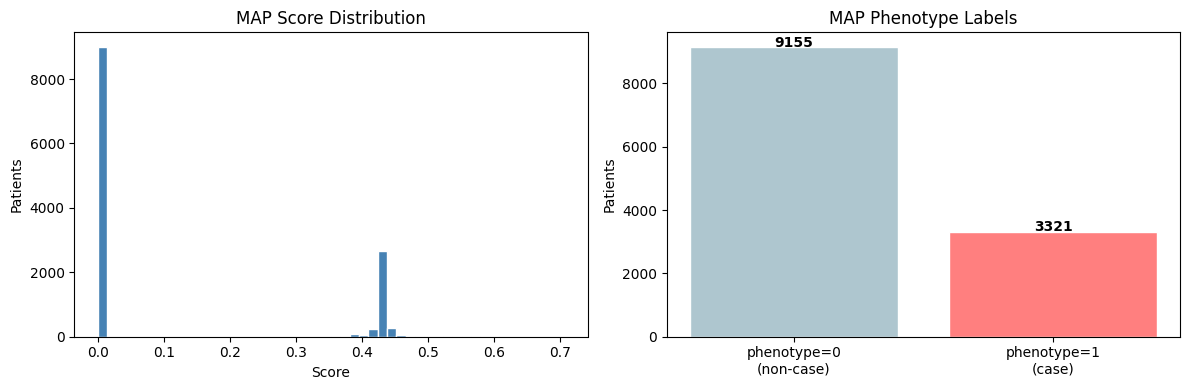

count    12476.000000
mean         0.120589
std          0.194398
min          0.000000
25%          0.000000
50%          0.000000
75%          0.418736
max          0.706790
Name: score, dtype: float64


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(map_results["score"], bins=50, edgecolor="white", color="steelblue")
axes[0].set_title("MAP Score Distribution")
axes[0].set_xlabel("Score")
axes[0].set_ylabel("Patients")

counts = map_results["phenotype"].value_counts().sort_index()
axes[1].bar(
    ["phenotype=0\n(non-case)", "phenotype=1\n(case)"],
    counts.values,
    color=["#aec6cf", "#ff7f7f"],
    edgecolor="white",
)
axes[1].set_title("MAP Phenotype Labels")
axes[1].set_ylabel("Patients")
for i, v in enumerate(counts.values):
    axes[1].text(i, v + 5, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

print(map_results["score"].describe())

In [30]:
# Sanity check: MAP cases should have higher RA ICD code counts than controls
scored = map_results.set_index("patient_id")
cases = scored[scored["phenotype"] == 1].index
controls = scored[scored["phenotype"] == 0].index

ra_counts = mat_df[MAIN_ICD_COL].rename("ra_phecode_count")
case_ra = ra_counts.reindex(cases).fillna(0)
ctrl_ra = ra_counts.reindex(controls).fillna(0)

print(f"=== PheCode {MAIN_ICD_COL} count -- MAP cases vs. controls ===")
print(
    f"  Cases    n={len(cases):,}    mean={case_ra.mean():.2f}  median={case_ra.median():.0f}"
)
print(
    f"  Controls n={len(controls):,}  mean={ctrl_ra.mean():.2f}  median={ctrl_ra.median():.0f}"
)
print(f"% MAP cases with >= 1 RA ICD code : {(case_ra > 0).mean() * 100:.1f}%")

=== PheCode 714.1 count -- MAP cases vs. controls ===
  Cases    n=3,321    mean=2.39  median=1
  Controls n=9,155  mean=0.03  median=0
% MAP cases with >= 1 RA ICD code : 100.0%


In [31]:
# Top 20 highest-scoring patients with RA ICD count and admission count
top_cases = (
    scored[["score", "phenotype"]]
    .join(mat_df[[MAIN_ICD_COL]].rename(columns={MAIN_ICD_COL: "ra_icd_count"}))
    .join(note_df.rename(columns={"note_count": "admissions"}))
    .sort_values("score", ascending=False)
    .head(20)
)
print("Top 20 patients by MAP score:")
top_cases

Top 20 patients by MAP score:


,score,phenotype,ra_icd_count,admissions
patient_id,,,,
15080981,0.706790,1,4,24
15261136,0.679252,1,4,38
11152968,0.650749,1,1,14
11778596,0.647245,1,1,14
12902597,0.646787,1,1,15
17295976,0.643843,1,2,83
15606858,0.601080,1,10,27
13151345,0.599916,1,4,6
12623286,0.598055,1,9,23


In [32]:
n_cases = int((map_results["phenotype"] == 1).sum())
prevalence = n_cases / len(map_results) * 100

print("=" * 50)
print("RA COHORT SUMMARY (MAP)")
print("=" * 50)
print(f"Study population        : {len(map_results):,} patients")
print(f"MAP cases (phenotype=1) : {n_cases:,}")
print(f"Estimated prevalence    : {prevalence:.1f}%")
print(f"Feature matrix          : {mat_df.shape[1]} ONCE features (PheCode)")
if NOTES_AVAILABLE:
    n_cui = sum(1 for c in mat_df.columns if c.startswith("C"))
    print(f"  + {n_cui} CUI (NLP) features")
print(
    f"Note count source       : {'MIMIC-IV-Note discharge notes' if NOTES_AVAILABLE else 'admission count (proxy)'}"
)

RA COHORT SUMMARY (MAP)
Study population        : 12,476 patients
MAP cases (phenotype=1) : 3,321
Estimated prevalence    : 26.6%
Feature matrix          : 23 ONCE features (PheCode)
Note count source       : admission count (proxy)
